# ViHSD — Baseline ML Models 
**TF-IDF + Logistic Regression | TF-IDF + SVM | XGBoost | LightGBM**

Dataset: [`sonlam1102/vihsd`](https://huggingface.co/datasets/sonlam1102/vihsd) — Vietnamese Hate Speech Detection  
Labels: `CLEAN (0)` · `OFFENSIVE (1)` · `HATE (2)`



## 1. install the library

In [21]:
!pip install datasets underthesea xgboost lightgbm optuna -q

## 2. Import lib and General Configurations

In [ ]:
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score,
)
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from xgboost import XGBClassifier
import lightgbm as lgb
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
tqdm.pandas()

# General Configurations
LABEL_NAMES = ['CLEAN', 'OFFENSIVE', 'HATE']
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

All imports ready.


## 3. Load Dataset

In [ ]:
path = "/kaggle/input/datasets/mnhtndev/vihsd-dataset"  # replace by your path
train_df = pd.read_csv(path + "/train.csv")
dev_df   = pd.read_csv(path + "/dev.csv")
test_df  = pd.read_csv(path + "/test.csv")

print(f"Train: {len(train_df):,} | Dev: {len(dev_df):,} | Test: {len(test_df):,}")
print(f"Columns: {train_df.columns.tolist()}")
print()

label_map = {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}
print("Label distribution (train):")
print(train_df['label_id'].value_counts().sort_index().rename(label_map))
train_df.head(3)

Train: 24,048 | Dev: 2,672 | Test: 6,680
Columns: ['free_text', 'label_id']

Label distribution (train):
label_id
CLEAN        19886
OFFENSIVE     1606
HATE          2556
Name: count, dtype: int64


,free_text,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction q...,0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt n...,2
2,Đậu Văn Cường giờ giống thằng sida hơn à,0


## 4. Preprocessing data

In [24]:
from underthesea import word_tokenize

# ===== Teencode dictionary =====
TEENCODE_MAP = {
    # Phủ định / Trạng thái
    'ko': 'không', 'kh': 'không', 'khong': 'không', 'kg': 'không',
    'hok': 'không', 'hk': 'không', 'hem': 'không', 'kô': 'không',
    'chx': 'chưa', 'chua': 'chưa',
    'r': 'rồi', 'rui': 'rồi', 'ròi': 'rồi', 'oy': 'rồi', 'uj': 'rồi',

    # Đại từ nhân xưng
    'mk': 'mình', 'mik': 'mình', 'mh': 'mình',
    'tui': 'tôi', 'tau': 'tao',
    'may': 'mày', 'mi': 'mày',
    'bn': 'bạn', 'ban': 'bạn',
    'no': 'nó', 'bon no': 'bọn nó', 'bọn no': 'bọn nó',
    'mng': 'mọi người', 'mn': 'mọi người', 'ae': 'anh em',

    # Động từ / Trạng từ
    'dc': 'được', 'đc': 'được', 'dk': 'được', 'đk': 'được',
    'đươc': 'được', 'duoc': 'được',
    'vs': 'với', 'voi': 'với',
    'j': 'gì', 'zì': 'gì', 'zi': 'gì',
    'ntn': 'như thế nào', 'nso': 'như sao',
    'biet': 'biết', 'bit': 'biết', 'hieu': 'hiểu', 'nghi': 'nghĩ',
    'muon': 'muốn', 'hoac': 'hoặc', 'neu': 'nếu', 'nen': 'nên',
    'giet': 'giết', 'chui': 'chửi', 'danh': 'đánh',

    # Liên từ / Trạng từ nối
    'nx': 'nhưng', 'nhg': 'nhưng', 'nhưg': 'nhưng', 'nma': 'nhưng mà',
    'cx': 'cũng', 'cg': 'cũng', 'cung': 'cũng', 'cũg': 'cũng',
    'ms': 'mới', 'boi': 'bởi',

    # Cảm thán
    'oke': 'ok', 'okie': 'ok', 'okê': 'ok', 'okey': 'ok',
    'uh': 'ừ', 'uk': 'ừ', 'uhm': 'ừ', 'ừm': 'ừ',
    'yep': 'đúng', 'yup': 'đúng',
    'haha': 'haha', 'hehe': 'hehe', 'hihi': 'hehe', 'huhu': 'buồn',
    'haiz': 'thở dài', 'haizz': 'thở dài', 'haizzz': 'thở dài',
    'wtf': 'cái gì vậy', 'omg': 'ôi trời',
    'lol': 'buồn cười', 'lmao': 'buồn cười',
    'fck': 'chửi thề', 'fk': 'chửi thề', 'gg': 'xong rồi', 'ez': 'dễ',

    # Trạng thái / Mô tả
    'bt': 'bình thường', 'bth': 'bình thường',
    'noob': 'tệ', 'nub': 'tệ', 'gà': 'tệ',
    'xàm': 'vô nghĩa', 'nhảm': 'vô nghĩa',
    'pro': 'giỏi',

    # Hate speech — biến thể chính tả cố ý
    'vl': 'vãi lồn', 'vcl': 'vãi cái lồn', 'vkl': 'vãi kép lồn',
    'vll': 'vãi lồn', 'vleu': 'vãi lồn', 'vloz': 'vãi lồn',
    'dm': 'đụ má', 'đm': 'đụ má', 'd.m': 'đụ má', 'đ.m': 'đụ má',
    'đmm': 'đụ má mày', 'dmm': 'đụ má mày',
    'đmcs': 'đụ má chúng mày', 'dmcs': 'đụ má chúng mày',
    'đtm': 'địt mẹ', 'dtm': 'địt mẹ',
    'cl': 'cái lồn', 'lon': 'lồn', 'loz': 'lồn', 'l0n': 'lồn',
    'clgt': 'cái lồn gì thế',
    'đéo': 'không', 'deo': 'không', 'éo': 'không',
    'cc': 'cái con', 'thg': 'thằng',
    'ngu': 'ngu', 'đần': 'đần độn', 'khùng': 'điên', 'dien': 'điên',
    'cút': 'cút', 'cut': 'cút',
    'câm': 'câm miệng', 'im mồm': 'câm miệng',

    # Mạng xã hội
    'fb': 'facebook', 'yt': 'youtube', 'tt': 'tiktok', 'zl': 'zalo',
    'ig': 'instagram', 'cmt': 'bình luận', 'rep': 'trả lời',

    # Địa danh
    'vn': 'việt nam', 'hn': 'hà nội', 'hcm': 'hồ chí minh', 'sg': 'sài gòn',

    # Khác
    'iu': 'yêu', 'ieu': 'yêu',
}


def normalize_text(text: str) -> str:
    """Chuẩn hóa văn bản tiếng Việt: lowercase, xóa noise, teencode."""
    if not isinstance(text, str):
        return ''

    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)       # URL
    text = re.sub(r'\b0[0-9]{9,10}\b', ' ', text)        # SĐT
    text = re.sub(r'\S+@\S+', ' ', text)                  # Email
    text = re.sub(r'<[^>]+>', ' ', text)                   # HTML
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)           # Ký tự lặp (aaa→aa)
    text = re.sub(r'[^\w\s]', ' ', text)                   # Ký tự đặc biệt
    text = re.sub(r'\s+', ' ', text).strip()               # Khoảng trắng thừa

    words = text.split()
    words = [TEENCODE_MAP.get(w, w) for w in words]
    return ' '.join(words)


def preprocess(text: str, use_word_segment: bool = True) -> str:
    """Pipeline: normalize → word segmentation (underthesea)."""
    text = normalize_text(text)
    if use_word_segment and text:
        try:
            text = word_tokenize(text, format='text')
        except Exception:
            pass
    return text


# Sanity check
sample = 'mày ko hiểu gì hết, ngu vcl!!'
print(f'Original : {sample}')
print(f'Processed: {preprocess(sample)}')

Original : mày ko hiểu gì hết, ngu vcl!!
Processed: mày không hiểu gì hết ngu_vãi cái lồn


## 5. Áp dụng tiền xử lý

In [ ]:
print('Preprocessing texts (word segmentation)...')

for df, name in [(train_df, 'Train'), (dev_df, 'Dev'), (test_df, 'Test')]:
    df['text_processed'] = df['free_text'].progress_apply(preprocess)
    print(f'  {name}: done')

print('\nSample:')
for _, row in train_df.sample(3, random_state=42).iterrows():
    lbl = label_map[row['label_id']]
    print(f'  [{lbl:>9}] {row["free_text"][:55]} → {row["text_processed"][:55]}')

Preprocessing texts (word segmentation)...
⏳ ~5-10 phút do tách từ underthesea


  0%|          | 0/24048 [00:00<?, ?it/s]

  Train: done


  0%|          | 0/2672 [00:00<?, ?it/s]

  Dev: done


  0%|          | 0/6680 [00:00<?, ?it/s]

  Test: done

Sample:
  [    CLEAN] Ko biết là 10.000 công nhân hay 10.000 lính @.@ → không biết là 10 00 công_nhân hay 10 00 lính
  [    CLEAN] Thằng → thằng
  [    CLEAN] Người ieu cua ai bắt về dùm đi cảm ơn ...cho nó hút khí → người yêu cua ai bắt về dùm đi cảm_ơn cho nó hút khí bo


## 6. TF-IDF Vectorization

In [26]:
X_train_text = train_df['text_processed'].fillna('').tolist()
X_dev_text   = dev_df['text_processed'].fillna('').tolist()
X_test_text  = test_df['text_processed'].fillna('').tolist()

y_train = train_df['label_id'].values
y_dev   = dev_df['label_id'].values
y_test  = test_df['label_id'].values

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b',
)

X_train = tfidf.fit_transform(X_train_text)
X_dev   = tfidf.transform(X_dev_text)
X_test  = tfidf.transform(X_test_text)

print(f'Vocab size: {len(tfidf.vocabulary_):,}')
print(f'X_train: {X_train.shape}  |  X_dev: {X_dev.shape}  |  X_test: {X_test.shape}')

Vocab size: 34,693
X_train: (24048, 34693)  |  X_dev: (2672, 34693)  |  X_test: (6680, 34693)


## 7. Evaluation Helpers

In [ ]:
results_table = []


def evaluate_model(name, model, X_eval, y_eval, split_name='Dev'):
    """Evaluate & return metrics dict. Appends to results_table."""
    y_pred = model.predict(X_eval)

    acc         = accuracy_score(y_eval, y_pred)
    f1_macro    = f1_score(y_eval, y_pred, average='macro')
    f1_weighted = f1_score(y_eval, y_pred, average='weighted')
    f1_cls      = f1_score(y_eval, y_pred, average=None)

    print(f'\n{"="*55}')
    print(f'  {name} — {split_name} Set')
    print(f'{"="*55}')
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  F1 Macro    : {f1_macro:.4f}')
    print(f'  F1 Weighted : {f1_weighted:.4f}')
    for i, lbl in enumerate(LABEL_NAMES):
        print(f'  F1 {lbl:>9}: {f1_cls[i]:.4f}')
    print()
    print(classification_report(y_eval, y_pred, target_names=LABEL_NAMES))

    res = {
        'Model': name, 'Split': split_name,
        'Accuracy': round(acc, 4),
        'F1 Macro': round(f1_macro, 4),
        'F1 Weighted': round(f1_weighted, 4),
        **{f'F1 {LABEL_NAMES[i]}': round(f1_cls[i], 4) for i in range(3)},
    }
    results_table.append(res)
    return res


def train_and_evaluate(name, model, X_tr, y_tr, X_d, y_d, X_te, y_te):
    """Train → evaluate on Dev & Test → return model."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    print(f'{name} — trained in {elapsed:.1f}s')

    evaluate_model(name, model, X_d, y_d, 'Dev')
    evaluate_model(name, model, X_te, y_te, 'Test')
    return model


Helpers ready.


## 8. Model 1 — TF-IDF + Logistic Regression

Tuning `C` bằng Optuna trên Dev set (F1 Macro).

In [28]:
def objective_lr(trial):
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    model = LogisticRegression(
        C=C, max_iter=1000, class_weight='balanced',
        solver='lbfgs', multi_class='multinomial',
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_dev)
    return f1_score(y_dev, y_pred, average='macro')


study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=20, show_progress_bar=True)

best_C = study_lr.best_params['C']
print(f'Best C = {best_C:.4f}  |  Best F1 Macro (Dev) = {study_lr.best_value:.4f}')

lr_model = LogisticRegression(
    C=best_C, max_iter=1000, class_weight='balanced',
    solver='lbfgs', multi_class='multinomial',
    random_state=RANDOM_STATE, n_jobs=-1,
)
lr_model = train_and_evaluate(
    'TF-IDF + LR (Tuned)', lr_model,
    X_train, y_train, X_dev, y_dev, X_test, y_test,
)

  0%|          | 0/20 [00:00<?, ?it/s]

Best C = 1.4982  |  Best F1 Macro (Dev) = 0.6151
TF-IDF + LR (Tuned) — trained in 3.1s

  TF-IDF + LR (Tuned) — Dev Set
  Accuracy    : 0.8099
  F1 Macro    : 0.6151
  F1 Weighted : 0.8239
  F1     CLEAN: 0.8993
  F1 OFFENSIVE: 0.4034
  F1      HATE: 0.5428

              precision    recall  f1-score   support

       CLEAN       0.94      0.86      0.90      2190
   OFFENSIVE       0.36      0.45      0.40       212
        HATE       0.45      0.68      0.54       270

    accuracy                           0.81      2672
   macro avg       0.59      0.66      0.62      2672
weighted avg       0.85      0.81      0.82      2672


  TF-IDF + LR (Tuned) — Test Set
  Accuracy    : 0.8244
  F1 Macro    : 0.6189
  F1 Weighted : 0.8368
  F1     CLEAN: 0.9075
  F1 OFFENSIVE: 0.4016
  F1      HATE: 0.5476

              precision    recall  f1-score   support

       CLEAN       0.94      0.87      0.91      5548
   OFFENSIVE       0.36      0.46      0.40       444
        HATE       0.47 

## 9. Model 2 — TF-IDF + SVM

Tuning `C` cho LinearSVC.

In [29]:
def objective_svm(trial):
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    base = LinearSVC(C=C, class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE)
    model = CalibratedClassifierCV(base, cv=3)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_dev)
    return f1_score(y_dev, y_pred, average='macro')


study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=15, show_progress_bar=True)

best_C_svm = study_svm.best_params['C']
print(f'Best C = {best_C_svm:.4f}  |  Best F1 Macro (Dev) = {study_svm.best_value:.4f}')

svm_base = LinearSVC(
    C=best_C_svm, class_weight='balanced', max_iter=3000, random_state=RANDOM_STATE,
)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model = train_and_evaluate(
    'TF-IDF + SVM (Tuned)', svm_model,
    X_train, y_train, X_dev, y_dev, X_test, y_test,
)

  0%|          | 0/15 [00:00<?, ?it/s]

Best C = 0.5321  |  Best F1 Macro (Dev) = 0.5839
TF-IDF + SVM (Tuned) — trained in 0.8s

  TF-IDF + SVM (Tuned) — Dev Set
  Accuracy    : 0.8634
  F1 Macro    : 0.5839
  F1 Weighted : 0.8406
  F1     CLEAN: 0.9315
  F1 OFFENSIVE: 0.2647
  F1      HATE: 0.5556

              precision    recall  f1-score   support

       CLEAN       0.89      0.98      0.93      2190
   OFFENSIVE       0.60      0.17      0.26       212
        HATE       0.62      0.50      0.56       270

    accuracy                           0.86      2672
   macro avg       0.71      0.55      0.58      2672
weighted avg       0.84      0.86      0.84      2672


  TF-IDF + SVM (Tuned) — Test Set
  Accuracy    : 0.8693
  F1 Macro    : 0.5785
  F1 Weighted : 0.8478
  F1     CLEAN: 0.9333
  F1 OFFENSIVE: 0.2727
  F1      HATE: 0.5296

              precision    recall  f1-score   support

       CLEAN       0.89      0.98      0.93      5548
   OFFENSIVE       0.61      0.18      0.27       444
        HATE       0.

## 10. Model 3 — TF-IDF + XGBoost
Tuning các hyperparameter chính bằng Optuna. GPU auto-fallback.

In [30]:
sample_weights = compute_sample_weight('balanced', y_train)

def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth':        trial.suggest_int('max_depth', 4, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
    }
    model = XGBClassifier(
        **params,
        use_label_encoder=False, eval_metric='mlogloss',
        objective='multi:softprob', num_class=3,
        tree_method='hist', device='cuda',  
        random_state=RANDOM_STATE, verbosity=0,
        early_stopping_rounds=50,
    )
    model.fit(
        X_train, y_train, sample_weight=sample_weights,
        eval_set=[(X_dev, y_dev)], verbose=False,
    )
    y_pred = model.predict(X_dev)
    return f1_score(y_dev, y_pred, average='macro')

print('Tuning XGBoost (20 trials)...')  
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)
print(f'Best F1 Macro (Dev) = {study_xgb.best_value:.4f}')
print(f'Best params: {study_xgb.best_params}')

bp = study_xgb.best_params
xgb_model = XGBClassifier(
    **bp,
    use_label_encoder=False, eval_metric='mlogloss',
    objective='multi:softprob', num_class=3,
    tree_method='hist', device='cuda',
    random_state=RANDOM_STATE, verbosity=1,
    early_stopping_rounds=50,
)

t0 = time.time()
xgb_model.fit(
    X_train, y_train, sample_weight=sample_weights,
    eval_set=[(X_dev, y_dev)], verbose=100,
)
print(f'Trained on CUDA in {time.time()-t0:.1f}s')

evaluate_model('TF-IDF + XGBoost (Tuned)', xgb_model, X_dev, y_dev, 'Dev')
evaluate_model('TF-IDF + XGBoost (Tuned)', xgb_model, X_test, y_test, 'Test')

Tuning XGBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

Best F1 Macro (Dev) = 0.5118
Best params: {'n_estimators': 700, 'max_depth': 5, 'learning_rate': 0.1211316658596367, 'subsample': 0.6699351339427133, 'colsample_bytree': 0.8671868477713175, 'min_child_weight': 6, 'reg_alpha': 0.6075453231385605, 'reg_lambda': 0.02282238871102768}
[0]	validation_0-mlogloss:1.06620
[75]	validation_0-mlogloss:0.92747
Trained on CUDA in 1.5s

  TF-IDF + XGBoost (Tuned) — Dev Set
  Accuracy    : 0.7878
  F1 Macro    : 0.5118
  F1 Weighted : 0.7859
  F1     CLEAN: 0.8861
  F1 OFFENSIVE: 0.2747
  F1      HATE: 0.3745

              precision    recall  f1-score   support

       CLEAN       0.88      0.89      0.89      2190
   OFFENSIVE       0.25      0.30      0.27       212
        HATE       0.44      0.33      0.37       270

    accuracy                           0.79      2672
   macro avg       0.52      0.51      0.51      2672
weighted avg       0.79      0.79      0.79      2672


  TF-IDF + XGBoost (Tuned) — Test Set
  Accuracy    : 0.7930
  F1 M

{'Model': 'TF-IDF + XGBoost (Tuned)',
 'Split': 'Test',
 'Accuracy': 0.793,
 'F1 Macro': 0.4843,
 'F1 Weighted': 0.7888,
 'F1 CLEAN': np.float64(0.8915),
 'F1 OFFENSIVE': np.float64(0.2584),
 'F1 HATE': np.float64(0.303)}

## 11. Model 4 — TF-IDF + LightGBM

Tuning LightGBM với Optuna + early stopping.

In [31]:
def objective_lgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 31, 127),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
    }
    model = lgb.LGBMClassifier(
        **params, class_weight='balanced',
        objective='multiclass', num_class=3,
        device='gpu', gpu_platform_id=0, gpu_device_id=0,  
        random_state=RANDOM_STATE, verbose=-1,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_dev, y_dev)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )
    y_pred = model.predict(X_dev)
    return f1_score(y_dev, y_pred, average='macro')

print('Tuning LightGBM (20 trials)...') 
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(objective_lgb, n_trials=20, show_progress_bar=True)
print(f'Best F1 Macro (Dev) = {study_lgb.best_value:.4f}')
print(f'Best params: {study_lgb.best_params}')

bp = study_lgb.best_params
lgb_model = lgb.LGBMClassifier(
    **bp,
    class_weight='balanced', objective='multiclass', num_class=3,
    device='gpu', gpu_platform_id=0, gpu_device_id=0,
    random_state=RANDOM_STATE, verbose=-1,
)

t0 = time.time()
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_dev, y_dev)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)
print(f'Trained on GPU in {time.time()-t0:.1f}s')

evaluate_model('TF-IDF + LightGBM (Tuned)', lgb_model, X_dev, y_dev, 'Dev')
evaluate_model('TF-IDF + LightGBM (Tuned)', lgb_model, X_test, y_test, 'Test')

Tuning LightGBM (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Best F1 Macro (Dev) = 0.6051
Best params: {'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.15694433437789615, 'num_leaves': 101, 'subsample': 0.8019164892161412, 'colsample_bytree': 0.7484483315394533, 'min_child_samples': 13, 'reg_alpha': 0.001319915867246801, 'reg_lambda': 3.653438239674484e-05}
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.675071
[200]	valid_0's multi_logloss: 0.607119
[300]	valid_0's multi_logloss: 0.57063
[400]	valid_0's multi_logloss: 0.548133
[500]	valid_0's multi_logloss: 0.534434
[600]	valid_0's multi_logloss: 0.524847
[700]	valid_0's multi_logloss: 0.517432
[800]	valid_0's multi_logloss: 0.513354
Did not meet early stopping. Best iteration is:
[800]	valid_0's multi_logloss: 0.513354
Trained on GPU in 18.0s

  TF-IDF + LightGBM (Tuned) — Dev Set
  Accuracy    : 0.8226
  F1 Macro    : 0.6051
  F1 Weighted : 0.8274
  F1     CLEAN: 0.9078
  F1 OFFENSIVE: 0.3844
  F1      HATE: 0.5229

              precision

{'Model': 'TF-IDF + LightGBM (Tuned)',
 'Split': 'Test',
 'Accuracy': 0.8314,
 'F1 Macro': 0.5954,
 'F1 Weighted': 0.835,
 'F1 CLEAN': np.float64(0.9125),
 'F1 OFFENSIVE': np.float64(0.351),
 'F1 HATE': np.float64(0.5226)}

## 12. Confusion Matrix

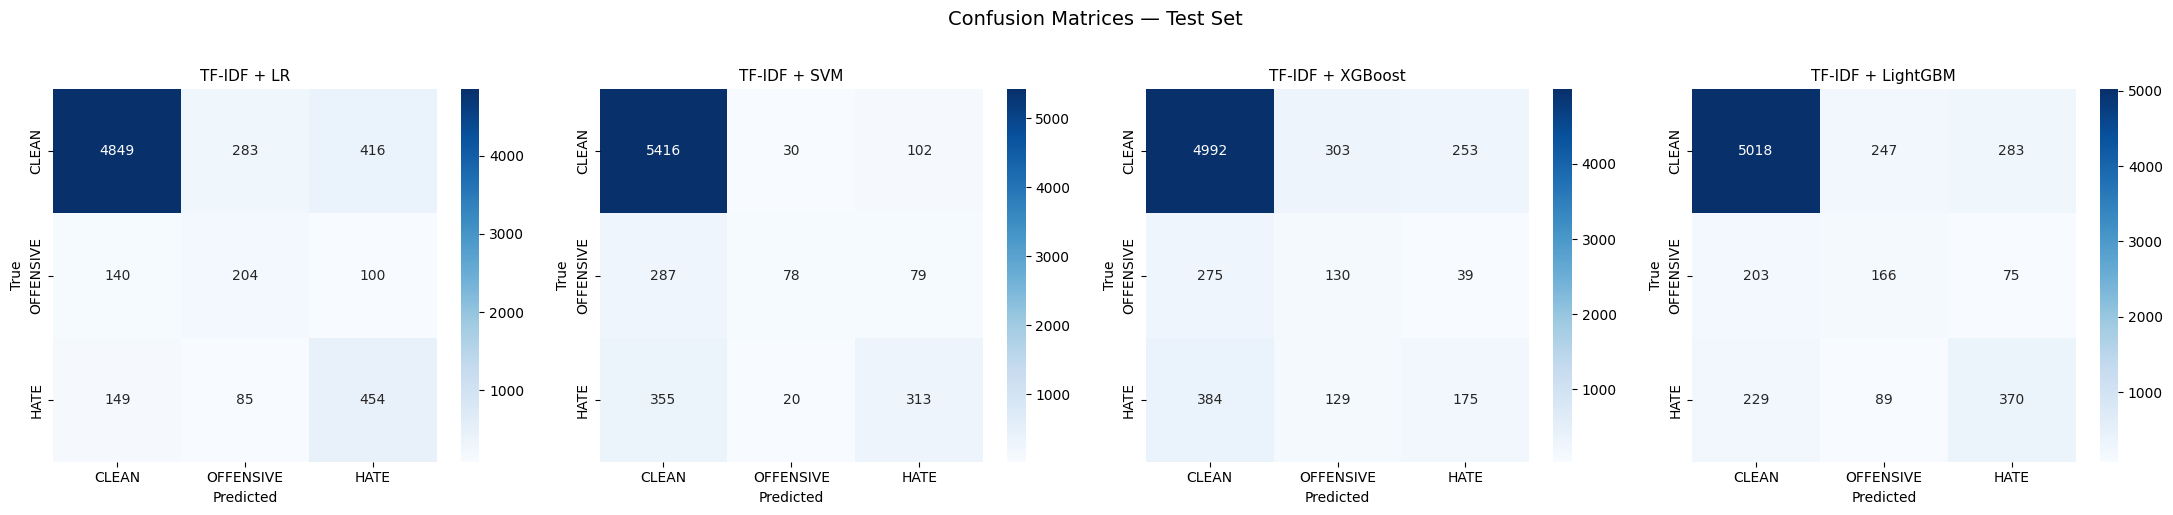

In [32]:
models_dict = {
    'TF-IDF + LR':       lr_model,
    'TF-IDF + SVM':      svm_model,
    'TF-IDF + XGBoost':  xgb_model,
    'TF-IDF + LightGBM': lgb_model,
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, model) in zip(axes, models_dict.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax,
    )
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Report

In [ ]:
results_df = pd.DataFrame(results_table)

test_results = (
    results_df[results_df['Split'] == 'Test']
    .drop('Split', axis=1)
    .sort_values('F1 Macro', ascending=False)
    .reset_index(drop=True)
)

print('\n' + '=' * 75)
print('  KẾT QUẢ TRÊN TEST SET — ViHSD Baseline ML (Tuned)')
print('=' * 75)
print(test_results.to_string(index=False))
print('=' * 75)

best = test_results.iloc[0]
print(f'\nBest model: {best["Model"]}  (F1 Macro = {best["F1 Macro"]})')


  KẾT QUẢ TRÊN TEST SET — ViHSD Baseline ML (Tuned)
                    Model  Accuracy  F1 Macro  F1 Weighted  F1 CLEAN  F1 OFFENSIVE  F1 HATE
      TF-IDF + LR (Tuned)    0.8244    0.6189       0.8368    0.9075        0.4016   0.5476
TF-IDF + LightGBM (Tuned)    0.8314    0.5954       0.8350    0.9125        0.3510   0.5226
     TF-IDF + SVM (Tuned)    0.8693    0.5785       0.8478    0.9333        0.2727   0.5296
 TF-IDF + XGBoost (Tuned)    0.7930    0.4843       0.7888    0.8915        0.2584   0.3030

🏆 Best model: TF-IDF + LR (Tuned)  (F1 Macro = 0.6189)


## 14. Visualization 

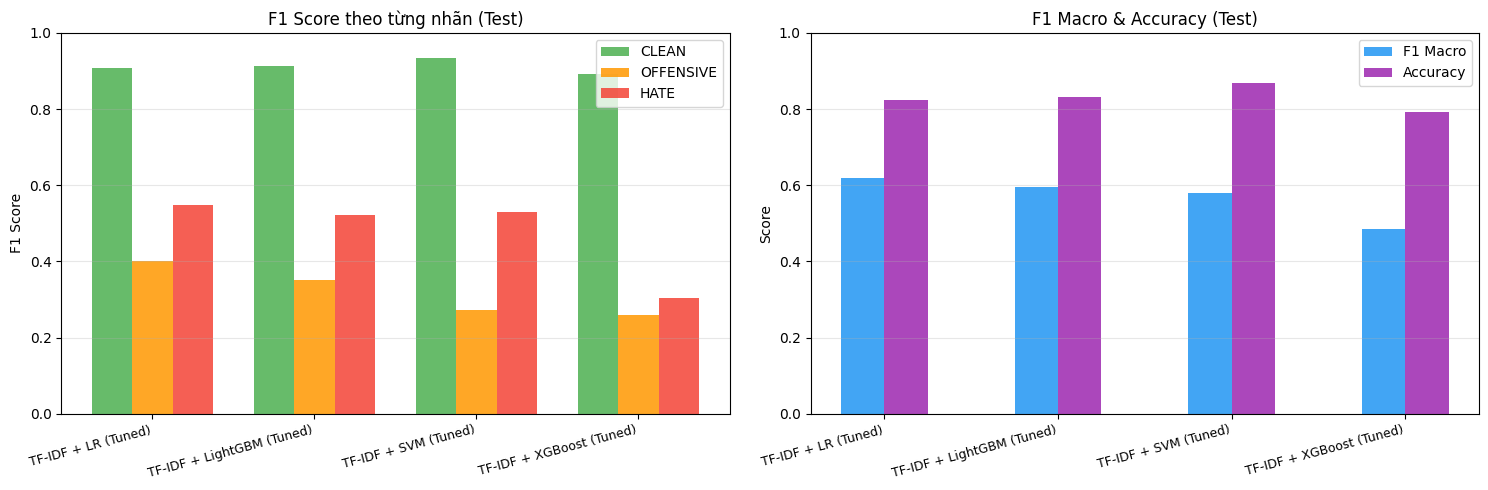

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
models_list = test_results['Model'].tolist()
x = np.arange(len(models_list))
w = 0.25

# F1 per class
ax = axes[0]
ax.bar(x - w, test_results['F1 CLEAN'],     w, label='CLEAN',     color='#4CAF50', alpha=0.85)
ax.bar(x,     test_results['F1 OFFENSIVE'],  w, label='OFFENSIVE', color='#FF9800', alpha=0.85)
ax.bar(x + w, test_results['F1 HATE'],       w, label='HATE',      color='#F44336', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score theo từng nhãn (Test)')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# F1 Macro + Accuracy
ax2 = axes[1]
ax2.bar(x - w/2, test_results['F1 Macro'], w, label='F1 Macro', color='#2196F3', alpha=0.85)
ax2.bar(x + w/2, test_results['Accuracy'], w, label='Accuracy', color='#9C27B0', alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(models_list, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel('Score')
ax2.set_title('F1 Macro & Accuracy (Test)')
ax2.legend()
ax2.set_ylim(0, 1.0)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Lưu models & kết quả

In [35]:
import joblib, os

os.makedirs('models', exist_ok=True)

joblib.dump(tfidf,     'models/tfidf_vectorizer.pkl')
joblib.dump(lr_model,  'models/lr_model.pkl')
joblib.dump(svm_model, 'models/svm_model.pkl')
xgb_model.save_model('models/xgb_model.json')
lgb_model.booster_.save_model('models/lgb_model.txt')

results_df.to_csv('baseline_ml_results.csv', index=False)

print('Saved:')
for f in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'  models/{f}  ({size:.0f} KB)')
print('  baseline_ml_results.csv')
print('  baseline_ml_results.png')
print('  confusion_matrices.png')

Saved:
  models/lgb_model.txt  (5622 KB)
  models/lr_model.pkl  (814 KB)
  models/svm_model.pkl  (2442 KB)
  models/tfidf_vectorizer.pkl  (1356 KB)
  models/xgb_model.json  (321 KB)
  baseline_ml_results.csv
  baseline_ml_results.png
  confusion_matrices.png


## 16. Optuna Tuning Summary

In [36]:
print('=== Optuna Best Trials ===\n')
for name, study in [('LR', study_lr), ('SVM', study_svm),
                     ('XGBoost', study_xgb), ('LightGBM', study_lgb)]:
    print(f'{name}: F1 Macro = {study.best_value:.4f}')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')
    print()

# Dev vs Test comparison
print('\n=== Dev vs Test ===')
pivot = results_df.pivot_table(
    index='Model', columns='Split',
    values=['Accuracy', 'F1 Macro', 'F1 HATE'],
    aggfunc='first',
)
print(pivot.to_string())

=== Optuna Best Trials ===

LR: F1 Macro = 0.6151
  C: 1.4982486442568443

SVM: F1 Macro = 0.5839
  C: 0.5320815556338343

XGBoost: F1 Macro = 0.5118
  n_estimators: 700
  max_depth: 5
  learning_rate: 0.1211316658596367
  subsample: 0.6699351339427133
  colsample_bytree: 0.8671868477713175
  min_child_weight: 6
  reg_alpha: 0.6075453231385605
  reg_lambda: 0.02282238871102768

LightGBM: F1 Macro = 0.6051
  n_estimators: 800
  max_depth: 8
  learning_rate: 0.15694433437789615
  num_leaves: 101
  subsample: 0.8019164892161412
  colsample_bytree: 0.7484483315394533
  min_child_samples: 13
  reg_alpha: 0.001319915867246801
  reg_lambda: 3.653438239674484e-05


=== Dev vs Test ===
                          Accuracy         F1 HATE         F1 Macro        
Split                          Dev    Test     Dev    Test      Dev    Test
Model                                                                      
TF-IDF + LR (Tuned)         0.8099  0.8244  0.5428  0.5476   0.6151  0.6189
TF-IDF + L

## 17. Predict để kiểm chứng nhanh

Nhập một câu bất kỳ và chạy dự đoán với từng model để kiểm chứng đầu ra.

In [ ]:
def predict_text(text, model, tfidf_vectorizer, label_names):
    """Preprocess + vectorize + predict 1 câu văn bản."""
    cleaned = preprocess(text)
    X_one = tfidf_vectorizer.transform([cleaned])
    pred_idx = int(model.predict(X_one)[0])
    pred_label = label_names[pred_idx]
    score_info = None
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_one)[0]
        score_info = {label_names[i]: float(probs[i]) for i in range(len(label_names))}
    return {
        'raw_text': text,
        'processed_text': cleaned,
        'pred_idx': pred_idx,
        'pred_label': pred_label,
        'scores': score_info,
    }

# ── Test cases: (text, expected_label) ──────────────────────
TEST_CASES = [
    ("Hôm nay trời đẹp quá, đi chơi thôi!",                   "CLEAN"),
    ("Tụi nó toàn nói nhảm, đúng là quá toxic",                "OFFENSIVE"),
    ("Đồ ngu, câm miệng lại đi mày",                           "OFFENSIVE"),
    ("Tao ghét cái loại người như mày, xéo đi cho khuất mắt",  "HATE"),
    ("Cảm ơn bạn đã giúp đỡ mình nhé!",                        "CLEAN"),
    ('Tao cảm ơn mày nhiều lắm',                              "CLEAN")
]

if 'models_dict' not in globals():
    models_dict = {
        'TF-IDF + LR':       lr_model,
        'TF-IDF + SVM':      svm_model,
        'TF-IDF + XGBoost':  xgb_model,
        'TF-IDF + LightGBM': lgb_model,
    }

print('=' * 70)
print('  PREDICT VERIFICATION')
print('=' * 70)

correct_counts = {name: 0 for name in models_dict}

for text, expected in TEST_CASES:
    print(f'\nInput    : {text}')
    print(f'Expected : {expected}')
    print(f'Processed: {preprocess(text)}')
    print(f'{"─" * 70}')
    print(f'  {"Model":<25} {"Predicted":<12} {"Match":<8} {"Probabilities"}')
    print(f'  {"─"*25} {"─"*12} {"─"*8} {"─"*25}')

    for name, mdl in models_dict.items():
        out = predict_text(text, mdl, tfidf, LABEL_NAMES)
        match = "OK" if out['pred_label'] == expected else "WRONG"
        if out['pred_label'] == expected:
            correct_counts[name] += 1

        if out['scores']:
            proba_str = ' | '.join([f'{k}: {v:.2f}' for k, v in out['scores'].items()])
        else:
            proba_str = 'N/A'

        print(f'  {name:<25} {out["pred_label"]:<12} {match:<8} {proba_str}')

#  Accuracy summary 
print(f'\n{"=" * 70}')
print(f'  SUMMARY ({len(TEST_CASES)} test cases)')
print(f'{"=" * 70}')
print(f'  {"Model":<25} {"Correct":<10} {"Accuracy":<10} {"Bar"}')
print(f'  {"─"*25} {"─"*10} {"─"*10} {"─"*10}')
for name, correct in correct_counts.items():
    acc = correct / len(TEST_CASES) * 100
    bar = '#' * correct + '.' * (len(TEST_CASES) - correct)
    print(f'  {name:<25} {correct}/{len(TEST_CASES):<8}  {acc:5.1f}%    {bar}')